In [2]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(__vsc_ipynb_file__), ".."))

import numpy as np
import numba
import matplotlib.pyplot as plt

from params import RestrepoParams
from cpu import *
from utils import time_renormalisation
from sde import mean_reverting_gbm, levy_ou_process

In [12]:
def ccdf(arr: npt.NDArray):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

In [13]:
nb_cru = RestrepoCPU()

In [14]:
nb_cru.forward(1e-3, 20_000_000)

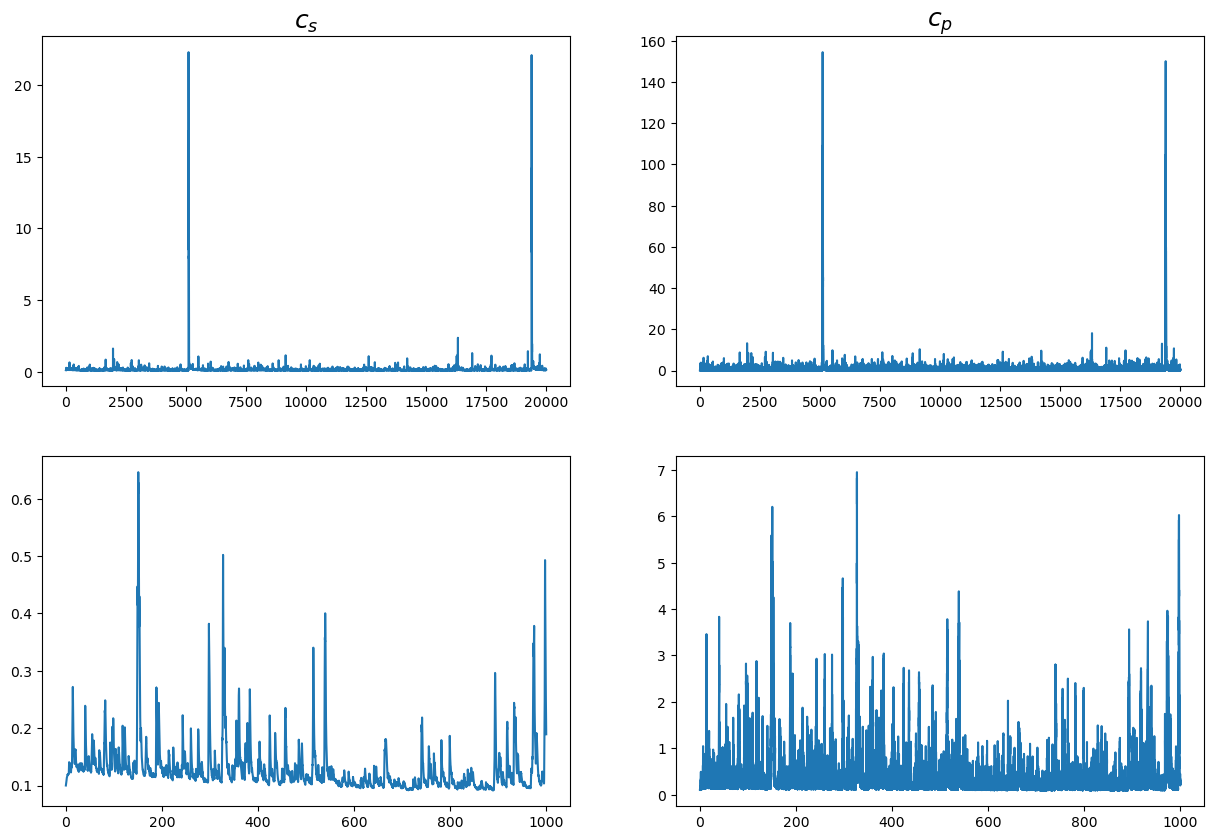

In [15]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(nb_cru.t, nb_cru.cs)
ax[1,0].plot(nb_cru.t[:1_000_000], nb_cru.cs[:1_000_000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(nb_cru.t, nb_cru.cp)
ax[1,1].plot(nb_cru.t[:1_000_000], nb_cru.cp[:1_000_000])
plt.show()

In [16]:
t_rn, cs_rn = time_renormalisation(nb_cru.cs, nb_cru.t, niter=10)
_, cp_rn = time_renormalisation(nb_cru.cp, nb_cru.t, niter=10)

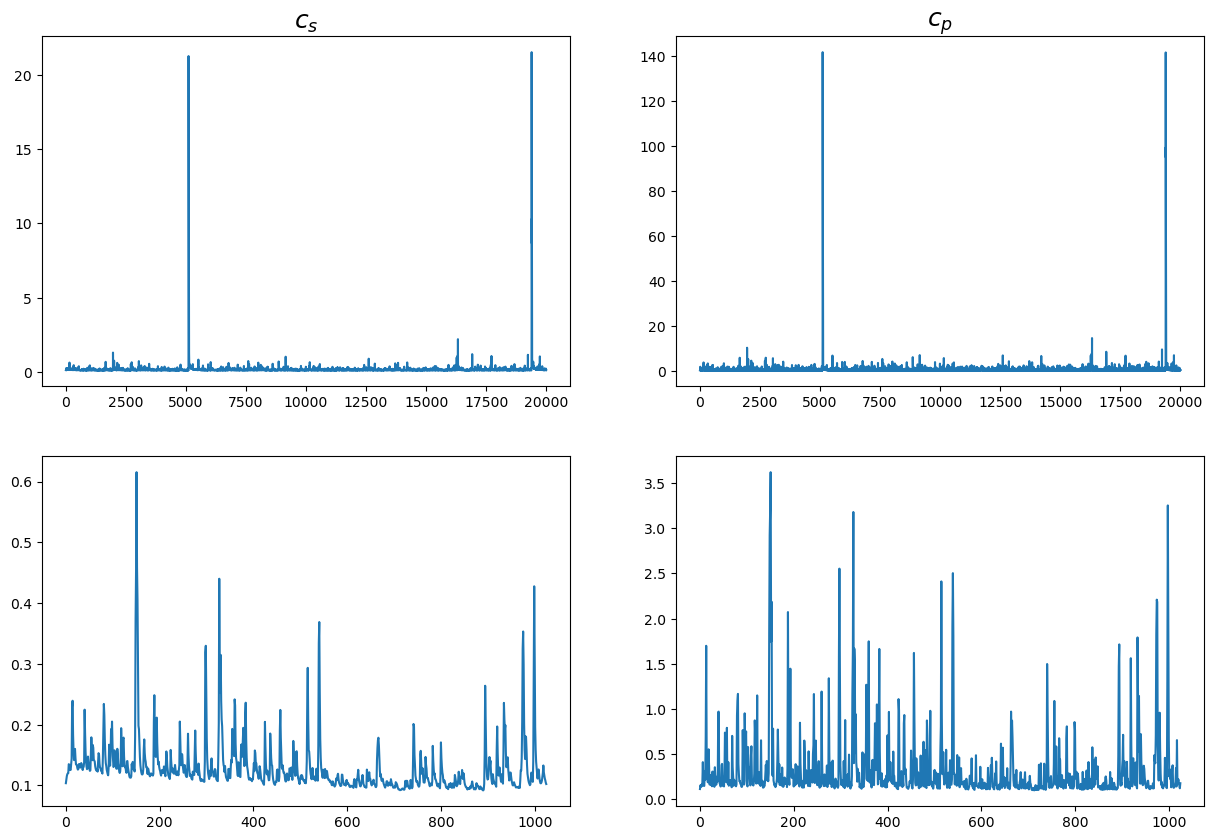

In [79]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(t_rn, cs_rn)
ax[1,0].plot(t_rn[:1000], cs_rn[:1000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(t_rn, cp_rn)
ax[1,1].plot(t_rn[:1000], cp_rn[:1000])
plt.show()

In [82]:
mu = cp_rn.mean()
r = 0.2
sigma = np.sqrt(2*r*(mu*(1/cp_rn).mean()-1))
ts, gbm = mean_reverting_gbm(mu, mu, sigma, r, 1e-3, 10_000_000)

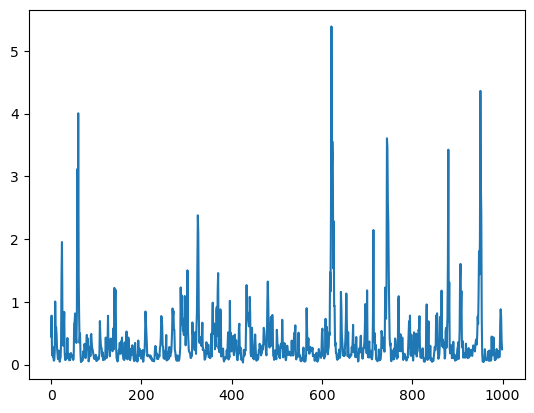

In [83]:
plt.plot(ts[:1_000_000:1000], gbm[:1_000_000:1000])
plt.show()

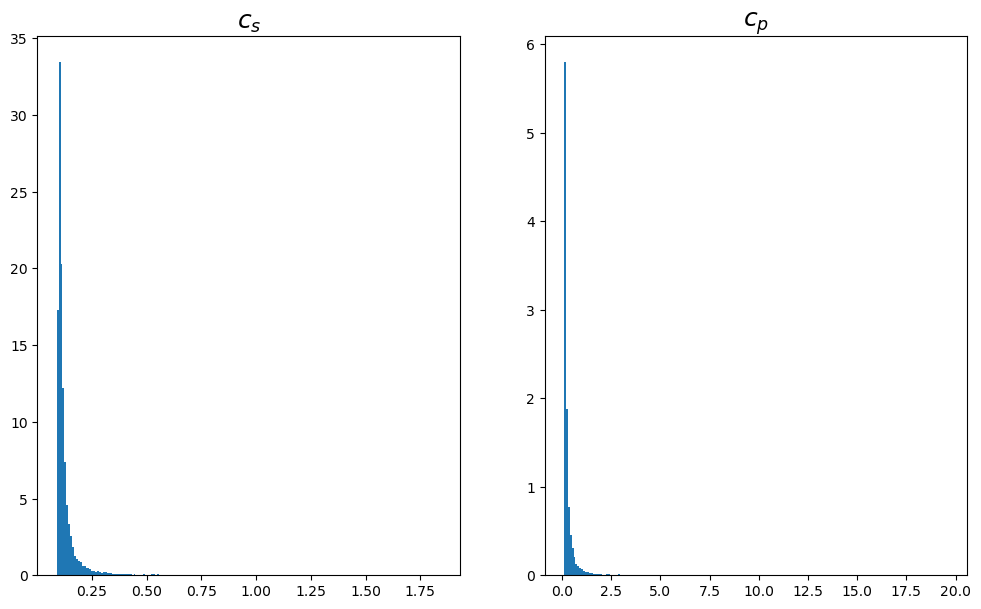

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(cs_rn[cs_rn < 2.0], bins=200, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn[cp_rn < 20], bins=200, density=True)
plt.show()

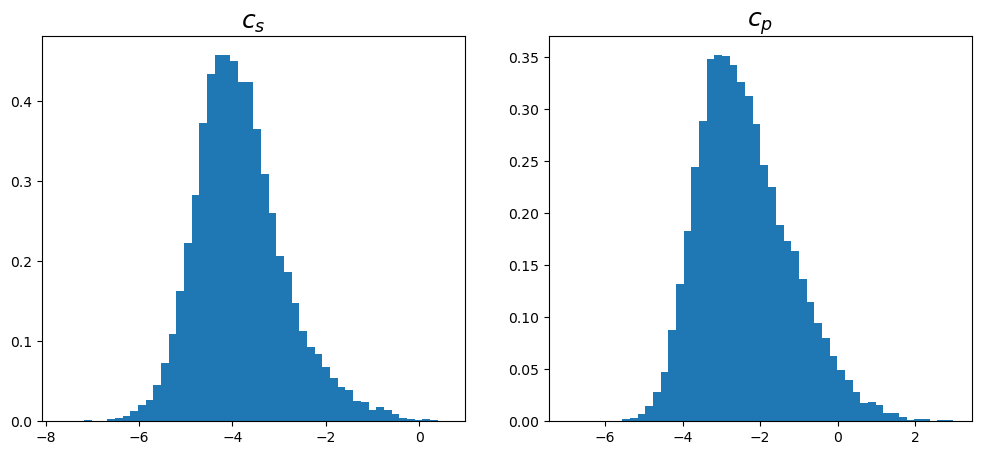

In [16]:
log_cs_shifted = np.log((np.sort(cs_rn[cs_rn < 2.0])[1:] - cs_rn.min()))
log_cp_shifted = np.log((np.sort(cp_rn[cp_rn < 20.0])[1:] - cp_rn.min()))

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(log_cs_shifted, bins=50, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(log_cp_shifted, bins=50, density=True)
plt.show()

In [18]:
m_cs = np.log(np.sort(cs_rn[cs_rn < 2.0])[1:] - cs_rn.min()).mean()
s_cs = np.log(np.sort(cs_rn[cs_rn < 2.0])[1:] - cs_rn.min()).std()
log_normals_cs = np.exp(m_cs + s_cs * np.random.normal(size=100_000))

m_cp = np.log(np.sort(cp_rn[cp_rn < 20.0])[1:] - cp_rn.min()).mean()
s_cp = np.log(np.sort(cp_rn[cp_rn < 20.0])[1:] - cp_rn.min()).std()
log_normals_cp = np.exp(m_cp + s_cp * np.random.normal(size=100_000))

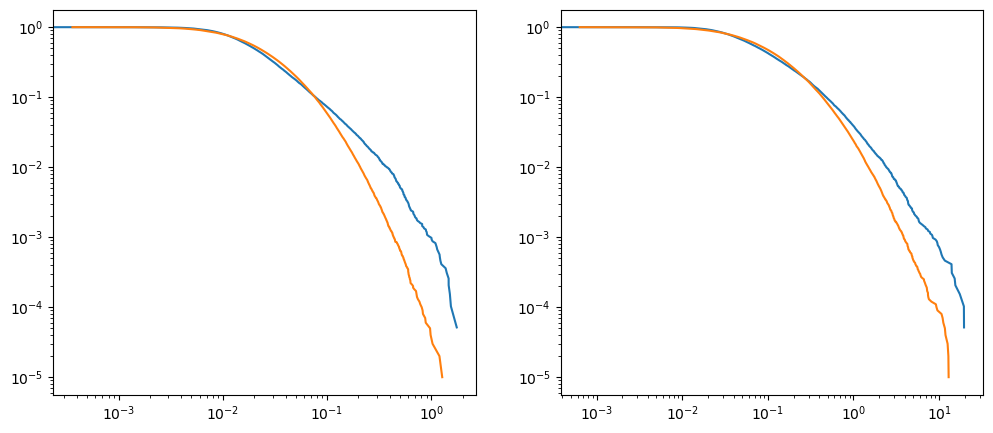

In [20]:
cs_ps, cs_bins = ccdf(cs_rn[cs_rn<2.0]-cs_rn.min())
cp_ps, cp_bins = ccdf(cp_rn[cp_rn<20.0]-cp_rn.min())

ln_cs_ps, ln_cs_bins = ccdf(log_normals_cs)
ln_cp_ps, ln_cp_bins = ccdf(log_normals_cp)

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(cs_bins, cs_ps)
ax[0].plot(ln_cs_bins, ln_cs_ps)
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].plot(cp_bins, cp_ps)
ax[1].plot(ln_cp_bins, ln_cp_ps)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.show()

In [21]:
def acf(arr: npt.NDArray, demean: bool = True):
    if demean:
        x = arr - arr.mean()
    else:
        x = arr

    corr = np.correlate(x, x, mode='full')
    corr /= np.dot(x, x)
    return corr[len(corr)//2:]

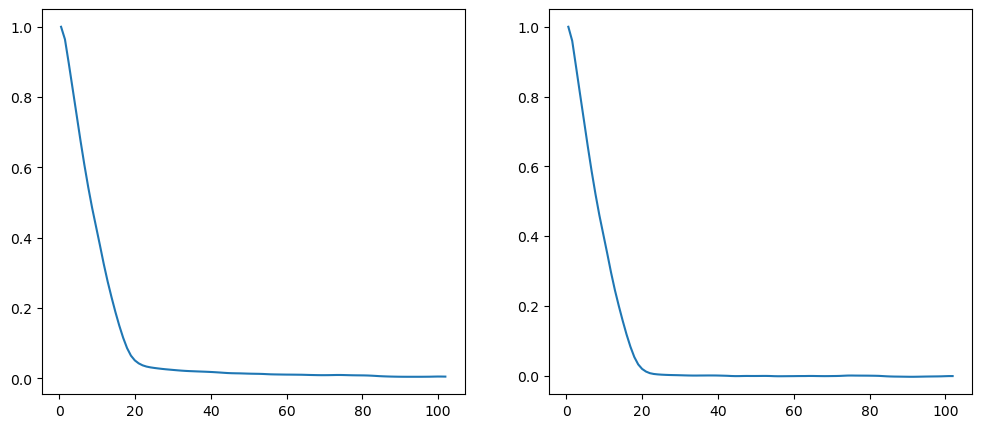

In [25]:
cs_acf = acf(cs_rn)
cp_acf = acf(cp_rn)

fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(t_rn[:100], cs_acf[:100])
ax[1].plot(t_rn[:100], cp_acf[:100])
plt.show()

In [26]:
# Delete big arrays
try:
    del nb_cru
except:
    pass

In [2]:
b_cru = RestrepoCPU(boundary=True)

In [50]:
V = -40.0
Nai = 78.0

In [87]:
b_cru.forward(1e-3, 50_000_000, V=V, Nai=Nai)

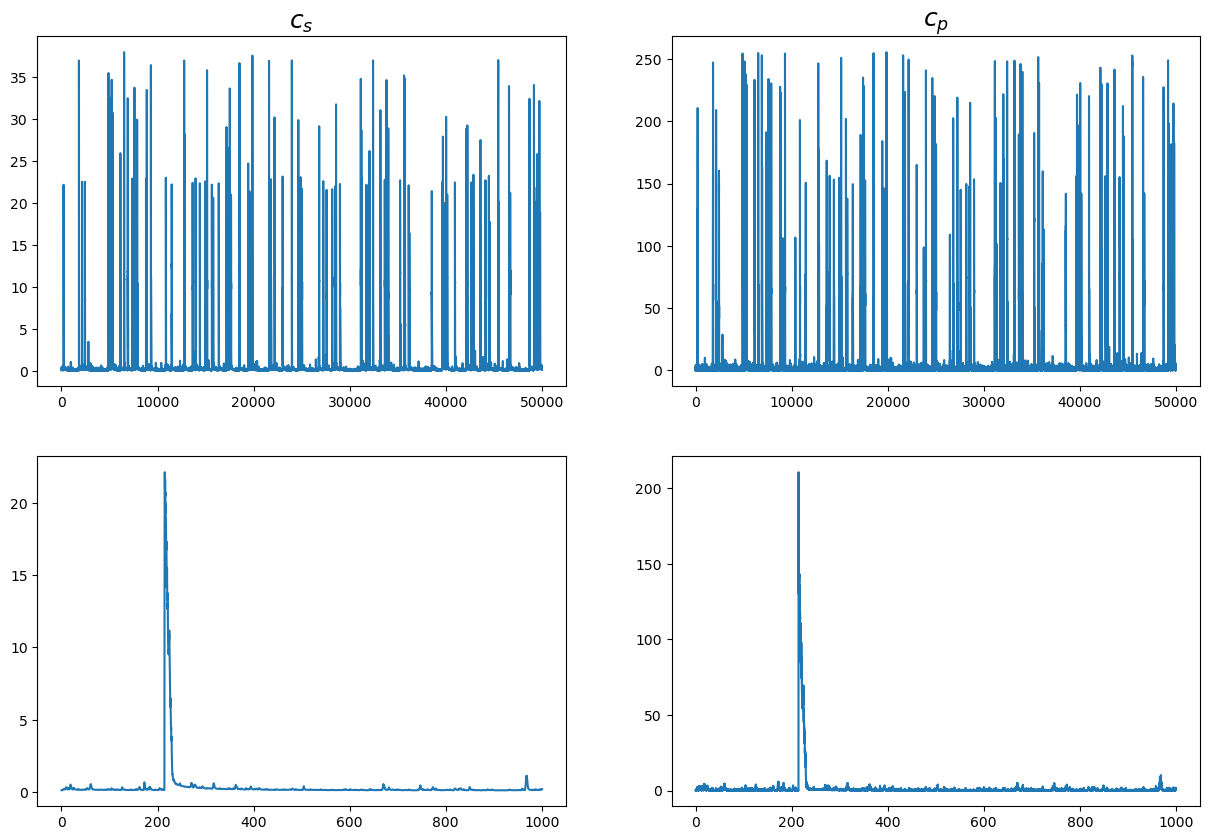

In [88]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(b_cru.t, b_cru.cs)
ax[1,0].plot(b_cru.t[:1_000_000], b_cru.cs[:1_000_000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(b_cru.t, b_cru.cp)
ax[1,1].plot(b_cru.t[:1_000_000], b_cru.cp[:1_000_000])
plt.show()

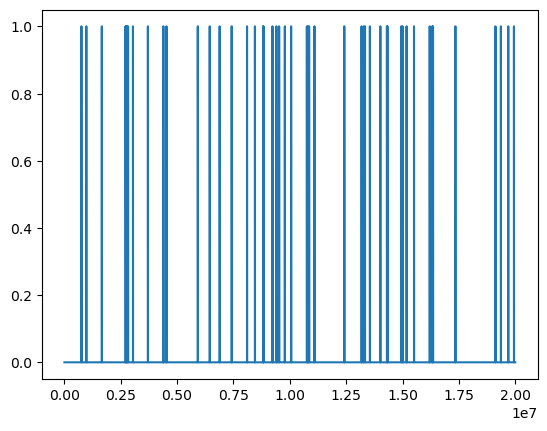

In [59]:
plt.plot((b_cru.LCC == 7).sum(axis=-1))
plt.show()

In [89]:
t_rn, cs_rn = time_renormalisation(b_cru.cs, b_cru.t, niter=10)
_, cp_rn = time_renormalisation(b_cru.cp, b_cru.t, niter=10)

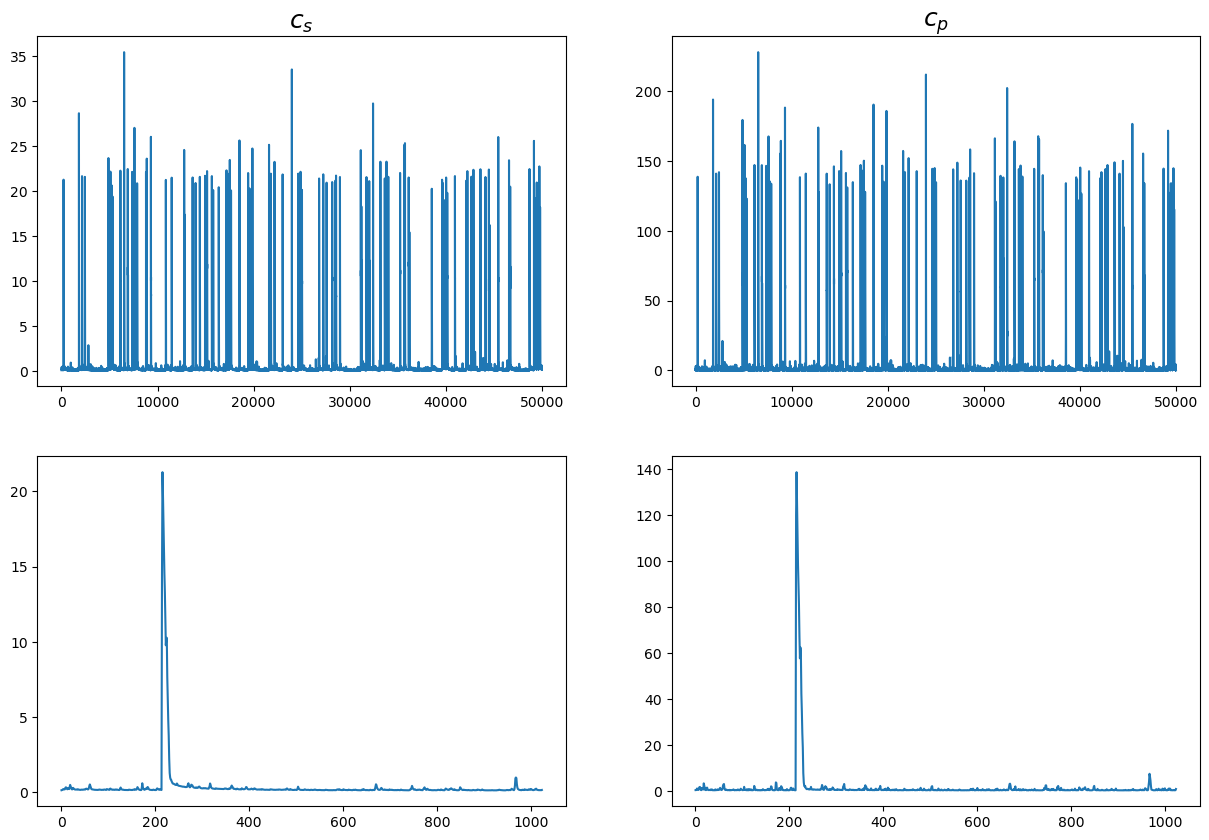

In [90]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(t_rn, cs_rn)
ax[1,0].plot(t_rn[:1000], cs_rn[:1000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(t_rn, cp_rn)
ax[1,1].plot(t_rn[:1000], cp_rn[:1000])
plt.show()

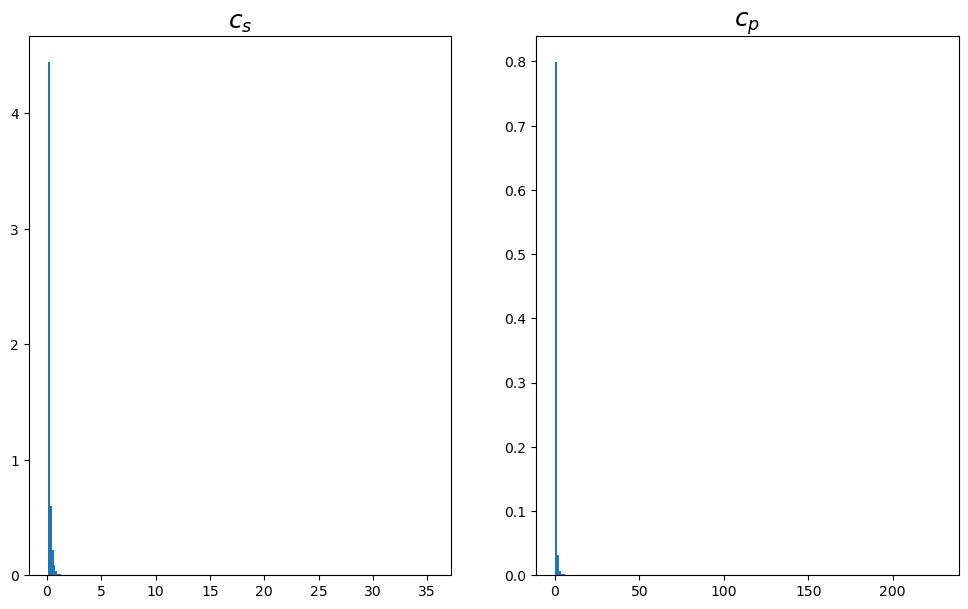

In [91]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(cs_rn, bins=200, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn, bins=200, density=True)
plt.show()

In [92]:
p_cp, bins_cp = ccdf(cp_rn)
p_cs, bins_cs = ccdf(cs_rn)

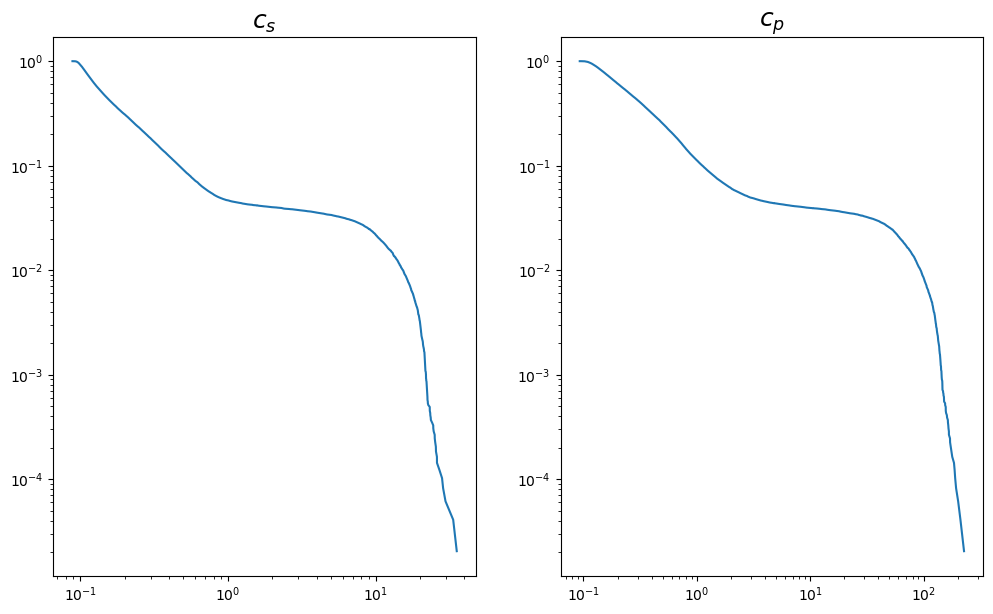

In [93]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].plot(bins_cs, p_cs)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].plot(bins_cp, p_cp)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.show()

In [94]:
jump_candidates = t_rn[np.where(cs_rn > 2.0)[0]]

In [95]:
actual_jump_pos = np.where(jump_candidates[1:] - jump_candidates[:-1] > 2.0)[0]

In [96]:
jumps = np.zeros(len(actual_jump_pos))
for i in range(len(actual_jump_pos)):
    if i == 0:
        left = 0
    else:
        left = actual_jump_pos[i-1]
    right = actual_jump_pos[i]
    jumps[i] = jump_candidates[left:right].mean()

In [97]:
ijt_ps, ijt_bins = ccdf(jumps[1:] - jumps[:-1])

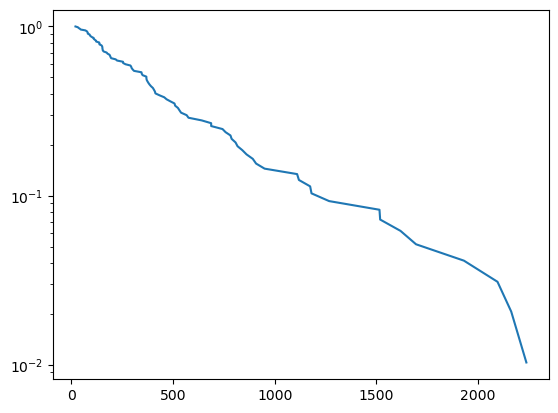

In [98]:
plt.plot(ijt_bins, ijt_ps)
plt.yscale('log')
plt.show()